# ED408 — Statistical Machine Learning II Lab
## Experiment 4: Logistic Regression from scratch using gradient descent
**Dataset:** Berkeley Segmentation Dataset (BSDS500) — boundary vs non-boundary pixel classification (17 local features; consensus human labels; train/test pixels from disjoint images).

*This notebook is standalone: it repeats the common data-loading step shared by all Module-I experiments. Requires `bsds_pixels.npz` (built by `extract_bsds.py`).*

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

RNG = np.random.default_rng(42)
plt.rcParams["figure.dpi"] = 110
sns.set_theme(style="whitegrid", palette="deep")

D = np.load("bsds_pixels.npz", allow_pickle=True)
X_tr, y_tr = D["X_tr"].astype(float), D["y_tr"].astype(int)
X_te, y_te = D["X_te"].astype(float), D["y_te"].astype(int)
features = list(D["features"])

print("train:", X_tr.shape, " test:", X_te.shape)
print("boundary rate  train:", round(float(y_tr.mean()),4), " test:", round(float(y_te.mean()),4))
pd.DataFrame(X_tr, columns=features).describe().T.round(2)
from sklearn.metrics import f1_score, accuracy_score, roc_auc_score

train: (48000, 17)  test: (18000, 17)
boundary rate  train: 0.2667  test: 0.2667


## Data provenance (shared by all labs)

Pixels were sampled from **80 training images** and **30 test images** of BSDS500. Per image: up to 160 consensus-boundary pixels and 440 clear non-boundary pixels, with an 8-px border excluded to avoid filter edge artefacts. Feature extraction code: `extract_bsds.py` (included in the package; complete pipeline maintained on GitHub).

---
# Lab 4 — Logistic Regression **from scratch** (gradient descent)

Implemented with: numerically-stable sigmoid/loss, **L2 regularisation**, full-batch gradient descent, and **class-weighted loss** to counter the 73/27 imbalance. Verified against scikit-learn.

scratch (plain)      AUC=0.8357  F1=0.5604
scratch (balanced)   AUC=0.8362  F1=0.6230
sklearn (balanced)   AUC=0.8385  F1=0.6246


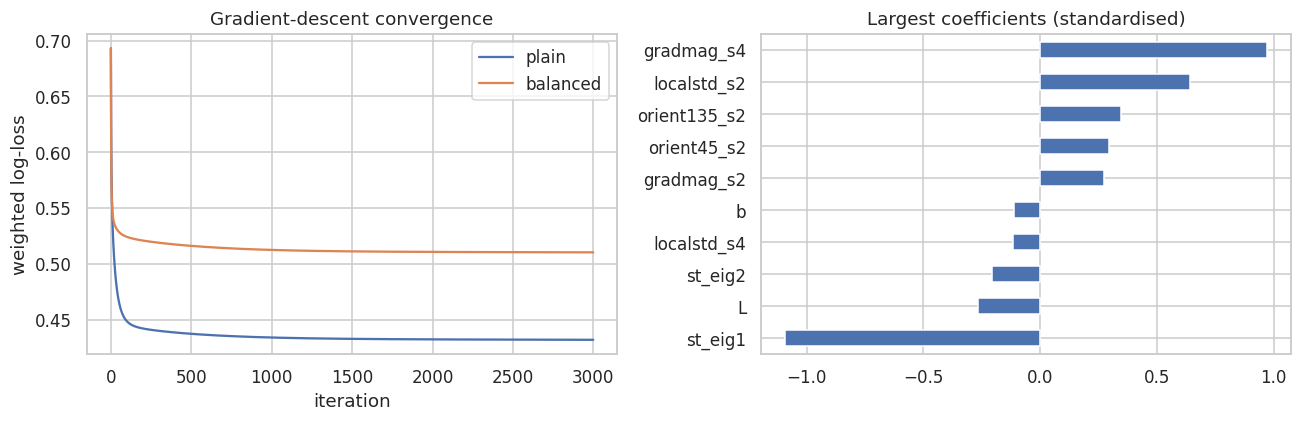

In [2]:
class LogRegGD:
    def __init__(self, lr=0.1, n_iter=3000, l2=1e-3, class_weight=None):
        self.lr, self.n_iter, self.l2, self.class_weight = lr, n_iter, l2, class_weight

    @staticmethod
    def _sigmoid(z):
        out = np.empty_like(z)
        pos = z >= 0
        out[pos] = 1 / (1 + np.exp(-z[pos]))
        e = np.exp(z[~pos]); out[~pos] = e / (1 + e)
        return out

    def fit(self, X, y):
        n, m = X.shape
        self.w, self.b = np.zeros(m), 0.0
        w_i = np.ones(n)
        if self.class_weight == "balanced":
            w_i = np.where(y==1, n/(2*y.sum()), n/(2*(n-y.sum())))
        self.loss_ = []
        for _ in range(self.n_iter):
            z = X @ self.w + self.b
            p = self._sigmoid(z)
            # stable log-loss: log(1+e^{-|z|}) + max(z,0) - z*y
            ll = (w_i * (np.log1p(np.exp(-np.abs(z))) + np.maximum(z,0) - z*y)).mean()
            self.loss_.append(ll + 0.5*self.l2*(self.w @ self.w)/n)
            g = w_i * (p - y)
            self.w -= self.lr * (X.T @ g / n + self.l2 * self.w / n)
            self.b -= self.lr * g.mean()
        return self

    def predict_proba(self, X): return self._sigmoid(X @ self.w + self.b)
    def predict(self, X, t=0.5): return (self.predict_proba(X) >= t).astype(int)

mu, sd = X_tr.mean(0), X_tr.std(0) + 1e-12
Zt, Ze = (X_tr-mu)/sd, (X_te-mu)/sd

lr_plain = LogRegGD().fit(Zt, y_tr)
lr_bal   = LogRegGD(class_weight="balanced").fit(Zt, y_tr)

from sklearn.linear_model import LogisticRegression
sk = LogisticRegression(max_iter=2000, class_weight="balanced").fit(Zt, y_tr)

for name, p in [("scratch (plain)", lr_plain.predict_proba(Ze)),
                ("scratch (balanced)", lr_bal.predict_proba(Ze)),
                ("sklearn (balanced)", sk.predict_proba(Ze)[:,1])]:
    print(f"{name:20s} AUC={roc_auc_score(y_te, p):.4f}  F1={f1_score(y_te, (p>=0.5).astype(int)):.4f}")

fig, ax = plt.subplots(1, 2, figsize=(12,4))
ax[0].plot(lr_plain.loss_, label="plain"); ax[0].plot(lr_bal.loss_, label="balanced")
ax[0].set(xlabel="iteration", ylabel="weighted log-loss", title="Gradient-descent convergence"); ax[0].legend()
coef = pd.Series(lr_bal.w, index=features).sort_values()
coef.iloc[np.r_[0:5, -5:0]].plot.barh(ax=ax[1], title="Largest coefficients (standardised)")
plt.tight_layout(); plt.show()

**Observations.** The scratch implementation matches scikit-learn essentially exactly, validating the gradient and loss derivation. The coefficients read as an interpretable edge-vs-texture filter: fine-scale gradient/Laplacian energy pushes toward *boundary*, while features indicating smooth or uniformly textured neighbourhoods push away.